# Hybrid framework search algorithm

In [1]:
import os
import io
import random
import logging
import torch
import json
import pickle
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter
from ultralytics import YOLO 
import torch.nn.functional as F
from tqdm import tqdm
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import probtools
from mylib import dqn
from mylib import tensortools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Set up logging
logging.getLogger().setLevel(logging.ERROR)

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [2]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[2]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]
    TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


[13:59:02:629731]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/iTHOR/FloorPlan220_physics.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordina

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()
scene_height = scene_dims[1]  # Height of the scene

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the topdown map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_map = myutils.retain_largest_white_chunk(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the grid map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map = myutils.map_to_rgb(grid_map)
grid_map = myutils.retain_largest_white_chunk(grid_map) # Filter 1
grid_resolution = grid_map.shape[:2]

# Free positions
grid_free_cells, map_free_cells, world_free_coords = [], [], []

# Occupied positions
grid_occ_cells, map_occ_cells, world_occ_coords = [], [], []

# Compute free and occupied: pass 1
for grid_x in range(grid_resolution[0]):
    for grid_y in range(grid_resolution[1]):
        # Convert grid coordinates to real world coordinates and then to top-down map coordinates
        real_world_z, real_world_x = maps.from_grid(grid_x, grid_y, grid_resolution, pathfinder=sim.pathfinder)
        map_x, map_y = maps.to_grid(real_world_z, real_world_x, topdown_resolution, pathfinder=sim.pathfinder)

        if not sim.pathfinder.is_navigable([real_world_x, 0.0, real_world_z]) or not topdown_map[map_x, map_y, 0] == 255 or not grid_map[grid_x, grid_y, 0] == 255:
            grid_map[grid_x, grid_y, :] = [128, 128, 128]  # Grey out non-navigable

# Filter 2
grid_map = myutils.retain_largest_white_chunk(grid_map)

# Compute free and occupied: pass 2
for grid_x in range(grid_resolution[0]):
    for grid_y in range(grid_resolution[1]):
        # Convert grid coordinates to real world coordinates and then to top-down map coordinates
        real_world_z, real_world_x = maps.from_grid(grid_x, grid_y, grid_resolution, pathfinder=sim.pathfinder)
        map_x, map_y = maps.to_grid(real_world_z, real_world_x, topdown_resolution, pathfinder=sim.pathfinder)

        if sim.pathfinder.is_navigable([real_world_x, 0.0, real_world_z]) and topdown_map[map_x, map_y, 0] == 255 and grid_map[grid_x, grid_y, 0] == 255:
            world_free_coords.append([real_world_x, 0.0, real_world_z])
            map_free_cells.append([map_x, map_y])
            grid_free_cells.append([grid_x, grid_y])
        else:
            world_occ_coords.append([real_world_x, 0.0, real_world_z])
            map_occ_cells.append([map_x, map_y])
            grid_occ_cells.append([grid_x, grid_y])

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

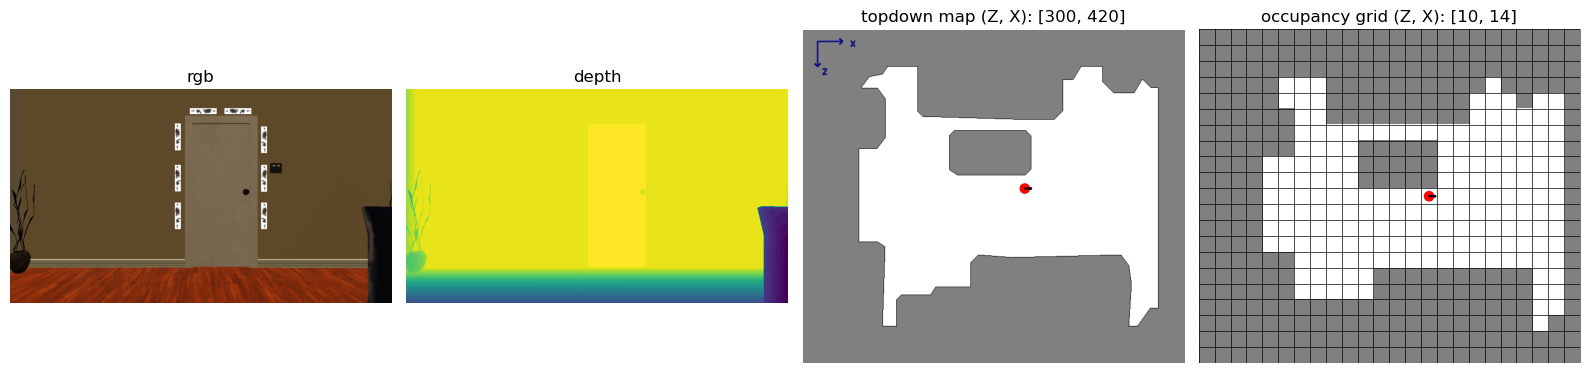

In [4]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

In [5]:
# Hyperparameters
gamma = 0.99
epsilon_start = 0.8
epsilon_end = 0.1
epsilon_decay = 100
batch_size = 64
lr = 1e-3
target_update_freq = 10
max_episodes = 25000
load_pretrained = True  # Set to False to train from scratch

# Simulation parameters
NUM_ACTIONS = len(ACTIONS)  # Number of actions available
MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform
DISPLAY_STEP = MAX_ITER // 10  # Display every 10% of the actions
DISPLAY_STEP = 1000  # Display every action for debugging

# DQN Network Parameters
PATCH_SIZE = 11  # Patch size for the DQN input

# Initialize DQN + target network
policy_net = dqn.ObjectSearchAgent(num_classes=NUM_CLASSES + 1, num_actions=NUM_ACTIONS, patch_size=PATCH_SIZE)
policy_net = policy_net.to(device)

# Load from file if exists
if load_pretrained and os.path.exists("dqn_policy.pth"):
    policy_net.load_state_dict(torch.load("dqn_policy.pth"))

# Initialize target network based on policy_net
target_net = dqn.ObjectSearchAgent(num_classes=NUM_CLASSES + 1, num_actions=NUM_ACTIONS, patch_size=PATCH_SIZE)
target_net.to(device)  # Move to same device as policy_net
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Set target network to evaluation mode

# Initialize optimizer and replay buffer
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
replay_buffer = dqn.SequenceReplayBuffer(capacity=1000, sequence_length=10)

# Epsilon schedule
def get_epsilon(episode):
    return epsilon_end + (epsilon_start - epsilon_end) * np.exp(-episode / epsilon_decay)

# Track performance
episode_lengths = []
episode_location_errors = []
episode_travelled_distances = []
episode_success_flags = []  
episode_rewards = []

# Main training loop
for episode in tqdm(range(max_episodes)):

    # LSTM vars
    episode_buffer = []
    hidden_state = None
    
    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")
    episode_reward = 0.0

    # Init agent state
    grid_position = random.choice(grid_free_cells)
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]
    agent_positions = (map_position, grid_position)

    agent_yaw = random.choice([0, 90, 180, 270])
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Set belief map
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

    # Set current state tensors
    pose = tensortools.init_pose_tensor(grid_position, grid_resolution, agent_yaw)
    occ_patch = tensortools.init_occupancy_patch(grid_position, grid_resolution, grid_map, PATCH_SIZE)
    belief_patch = tensortools.init_belief_patch(grid_position, grid_resolution, grid_map, belief_map, PATCH_SIZE, NUM_CLASSES + 1)
    target_object_id = torch.tensor([TARGET_OBJECT_CLASS_ID], dtype=torch.long, device=device)  # Shape [1]
    
    # Run episode
    while not target_found and num_actions < MAX_ITER:

        # Get epsilon for exploration
        epsilon = get_epsilon(episode)

        # Select action using epsilon-greedy 
        policy_net.eval()  # Set policy network to evaluation mode
        action, hidden_state = dqn.select_action(policy_net, pose, occ_patch, belief_patch, target_object_id, NUM_ACTIONS, hidden_state, epsilon)
        action_str = list(ACTIONS)[action]  # Convert action index to action string

        # Perform action if valid
        if simtools.is_action_valid(action_str, grid_position, agent_yaw, grid_free_cells):
            grid_position, agent_yaw = simtools.perform_action(action_str, grid_position, agent_yaw)

        # Update agent position and state
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_positions = (map_position, grid_position)
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)

        # Update metrics
        num_actions += 1
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

        # Update agent state
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Get observations
        obs = sim.get_sensor_observations(0)
        rgb, depth = obs["color_sensor"], obs["depth_sensor"]

        # YOLO Prediction
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
        
        # Initialize processed cells
        processed_cells = []

        # Process the observations
        for det in detections:
            box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
            scale = myutils.compute_bbox_scale(box, rgb)

            # Center of bbox and depth value
            center_x, center_y = simtools.get_box_center(box)
            depth_value = depth[center_y, center_x]

            # Project to real world, grid and map coords
            camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
            object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
            object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

            # Check if projected cell is outside free grid cells
            if object_grid_position in grid_free_cells:
                object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

            # Add this cell to processed cells
            if tuple(object_grid_position) not in processed_cells:
                processed_cells.append(tuple(object_grid_position))

            # Likelihood vector: likelihood of each class (Rule 1)
            likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

            # Kaplan Update to the belief map in that cell
            grid_x, grid_y = object_grid_position
            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

        # Compute every theoretically visible occupied cell
        rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
        visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
        
        # Go through every visible occupied cell and update the belief map
        for cell in visible_occ_cells:
            if tuple(cell) not in processed_cells:
                # Compute distance to the cell
                grid_x, grid_y = cell
                distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                # Compute the likelihood vector for the cell (Rule 2)
                likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                # Kaplan update to the belief map in that cell
                belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

        # Check if the target object was found in the current observations
        if target_found:
            # Real world position
            center_x, center_y = simtools.get_box_center(target_bbox)
            depth_value = depth[center_y, center_x]
            target_object_position = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
            location_error = simtools.compute_location_error(target_object_position, REAL_TARGET_LOCATION)

            # Check if location error
            if location_error > LOCATION_ERROR_THRESHOLD:
                target_found = False
                location_error = float("inf")

        # Check if the target object was found in the belief map
        if not target_found:
            target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)

            if target_found:
                # Real world position
                target_object_position = world_coords[grid_cells.index(target_grid_position)]
                location_error = simtools.compute_location_error(target_object_position, REAL_TARGET_LOCATION)

                # Check if location error
                if location_error > LOCATION_ERROR_THRESHOLD:
                    target_found = False
                    location_error = float("inf")

        # Compute next state
        next_pose = tensortools.init_pose_tensor(grid_position, grid_resolution, agent_yaw)
        next_occ_patch = tensortools.init_occupancy_patch(grid_position, grid_resolution, grid_map, PATCH_SIZE)
        next_belief_patch = tensortools.init_belief_patch(grid_position, grid_resolution, grid_map, belief_map, PATCH_SIZE, NUM_CLASSES + 1)
        next_target_object_id = target_object_id

        # Compute reward
        if target_found: # If the target object was found
            reward = 10.0
        elif torch.equal(next_pose, pose):  # If the agent did not move
            reward = -0.5
        else: # Step penalty
            reward = -0.01
       
        # Display the simulation state 
        if num_actions % DISPLAY_STEP == 0:
            print(f"\n\nEpisode: {episode} | Iteration: {num_actions} | Action: {action_str} | Epsilon: {epsilon:.3f}")
            entropy_map = simtools.compute_entropy_map(belief_map, grid_map)
            simtools.display_topdown_and_entropy_maps_only(topdown_map, grid_map, entropy_map, agent_positions, agent_radius, agent_yaw)

        episode_buffer.append((pose, occ_patch, belief_patch, target_object_id, action, reward, next_pose, next_occ_patch, next_belief_patch, next_target_object_id, target_found))

        # Update variables
        pose = next_pose
        occ_patch = next_occ_patch
        belief_patch = next_belief_patch
        target_object_id = next_target_object_id 
        episode_reward += reward

    # Push the episode buffer to the replay buffer
    replay_buffer.push_episode(episode_buffer)

    # Train the policy DQN
    if len(replay_buffer) >= batch_size:
        # Sample and train
        poses, occ_patches, belief_patches, target_object_ids, actions, rewards, next_poses, next_occ_patches, next_belief_patches, next_target_object_ids, dones = replay_buffer.sample(batch_size)

        policy_net.train()  # Set policy network to training mode
        q_values, _ = policy_net(poses, occ_patches, belief_patches, target_object_ids)
        next_q_values, _ = target_net(next_poses, next_occ_patches, next_belief_patches, next_target_object_ids)
        q_values = q_values.gather(2, actions.unsqueeze(2)).squeeze(2)
        next_q_values_max = next_q_values.max(2)[0]  # Max over actions
        targets = rewards + gamma * next_q_values_max * (1 - dones.float())
        loss = F.mse_loss(q_values, targets.detach())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Update target network
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Print message
    # if target_found:
    #     print(f"Target object <{TARGET_OBJECT}> found. SUCCESS!")
    #     # print(f"Found location: {target_object_position}")
    #     # print(f"Real location: {REAL_TARGET_LOCATION}")
    # else:
    #     print(f"\nTarget object <{TARGET_OBJECT}> not found. FAILURE!")

    # Append metrics
    episode_lengths.append(num_actions)
    episode_location_errors.append(location_error)
    episode_travelled_distances.append(travelled_distance)
    episode_success_flags.append(target_found)
    episode_rewards.append(episode_reward)

    # Print episode summary
    # print(f"Number of actions: {num_actions}")
    # print(f"Travelled distance: {travelled_distance:.2f} m")
    # print(f"Computed location error: {location_error:.3f} m")
    # print(f"Episode: {episode} | Reward: {episode_reward:.2f} | Steps: {num_actions} | Epsilon: {epsilon:.3f}")

# After training, save the model
torch.save(policy_net.state_dict(), "dqn_policy.pth")

100%|██████████| 25000/25000 [72:09:33<00:00, 10.39s/it]   
